In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.Draw import IPythonConsole
import numpy as np


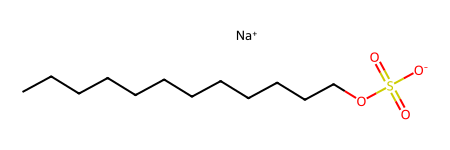

In [7]:
smile = "CCCCCCCCCCCCOS(=O)(=O)[O-].[Na+]"

mol = Chem.MolFromSmiles(smile)

mol

In [4]:
#for atom in mol.GetAtoms():
    #print(atom.GetSymbol())

#for bond in mol.GetBonds():
    #print(bond.GetBondType())

# Generate descriptors
molwt = Descriptors.MolWt(mol)
logp = Descriptors.MolLogP(mol)
tpsa = Descriptors.TPSA(mol)
h_donors = Descriptors.NumHDonors(mol)
h_acceptors = Descriptors.NumHAcceptors(mol)
ring_count = Descriptors.RingCount(mol)
heavy_atoms = Descriptors.HeavyAtomCount(mol)
rotatable_bonds = Descriptors.NumRotatableBonds(mol)

# Print results
print("Molecular Weight (MolWt):", molwt)
print("LogP (MolLogP):", logp)
print("Topological Polar Surface Area (TPSA):", tpsa)
print("Hydrogen Bond Donors:", h_donors)
print("Hydrogen Bond Acceptors:", h_acceptors)
print("Ring Count:", ring_count)
print("Heavy Atom Count:", heavy_atoms)
print("Rotatable Bonds:", rotatable_bonds)


Molecular Weight (MolWt): 282.424
LogP (MolLogP): 2.3316000000000003
Topological Polar Surface Area (TPSA): 60.69
Hydrogen Bond Donors: 3
Hydrogen Bond Acceptors: 3
Ring Count: 3
Heavy Atom Count: 20
Rotatable Bonds: 1


| Descriptor          | Meaning            | Why useful for surfactants                |
| ------------------- | ------------------ | ----------------------------------------- |
| `MolWt`             | Molecular weight   | Larger surfactants often lower CMC        |
| `MolLogP`           | Hydrophobicity     | Important for micelle formation           |
| `TPSA`              | Polar surface area | Relates to hydrophilic headgroup behavior |
| `NumHDonors`        | H-bond donors      | Affects water interactions                |
| `NumHAcceptors`     | H-bond acceptors   | Impacts solubility                        |
| `RingCount`         | Number of rings    | Aromatic surfactants behave differently   |
| `HeavyAtomCount`    | Non-hydrogen atoms | Rough molecular size indicator            |
| `NumRotatableBonds` | Flexibility        | Impacts packing and aggregation           |


In [ ]:
#alkyl_tail_length ≈ number of carbon atoms in hydrophobic chain is the goal
#Need to count alklyl chain from the hydrophoic headgroup while considering branching or cylic structures
#currently its finding what the neighbors are

def alkyl_tail_length(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan

    max_c = 0

    for atom in mol.GetAtoms():
        if atom.GetSymbol() == 'C':
            c_neighbors = sum(1 for n in atom.GetNeighbors() if n.GetSymbol() == 'C')
            max_c = max(max_c, c_neighbors)

    return max_c

alklyl_length = alkyl_tail_length(smile)
print(alklyl_length)

2
